In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)


100%|██████████| 170M/170M [00:03<00:00, 48.4MB/s]


In [3]:
class CNN_NoBN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x=self.conv(x)
        x=x.view(x.size(0),-1)
        x=self.fc(x)
        return x


In [4]:
class CNN_BN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x=self.conv(x)
        x=x.view(x.size(0),-1)
        x=self.fc(x)
        return x


In [5]:
def train_model(model,epochs=10):

    device='cuda' if torch.cuda.is_available() else 'cpu'
    model=model.to(device)

    criterion=nn.CrossEntropyLoss()
    optimizer=optim.Adam(model.parameters(),lr=0.001)

    train_losses=[]

    for epoch in range(epochs):

        total_loss=0

        for images,labels in trainloader:

            images,labels=images.to(device),labels.to(device)

            optimizer.zero_grad()

            outputs=model(images)

            loss=criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            total_loss+=loss.item()

        avg_loss=total_loss/len(trainloader)

        train_losses.append(avg_loss)

        print(f"Epoch {epoch+1}: Loss {avg_loss:.4f}")

    return train_losses


In [6]:
model_no_bn = CNN_NoBN()
loss_no_bn = train_model(model_no_bn)

model_bn = CNN_BN()
loss_bn = train_model(model_bn)


Epoch 1: Loss 1.5280
Epoch 2: Loss 1.1514
Epoch 3: Loss 1.0020
Epoch 4: Loss 0.9019
Epoch 5: Loss 0.8275
Epoch 6: Loss 0.7499
Epoch 7: Loss 0.6875
Epoch 8: Loss 0.6267
Epoch 9: Loss 0.5667
Epoch 10: Loss 0.4988
Epoch 1: Loss 1.2781
Epoch 2: Loss 0.9215
Epoch 3: Loss 0.7957
Epoch 4: Loss 0.7090
Epoch 5: Loss 0.6299
Epoch 6: Loss 0.5613
Epoch 7: Loss 0.5023
Epoch 8: Loss 0.4397
Epoch 9: Loss 0.3844
Epoch 10: Loss 0.3313


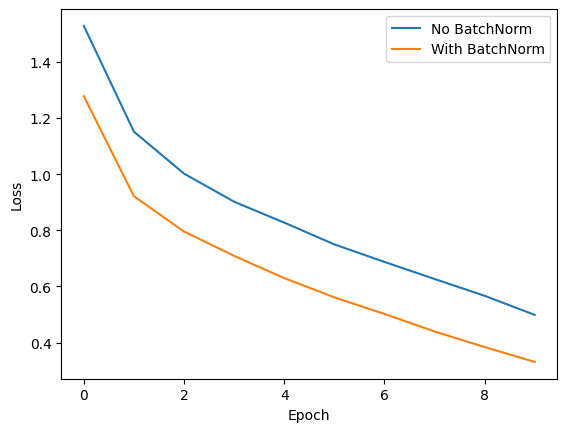

In [7]:
plt.plot(loss_no_bn,label="No BatchNorm")
plt.plot(loss_bn,label="With BatchNorm")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [9]:
def evaluate(model):

    device='cuda' if torch.cuda.is_available() else 'cpu'
    model=model.to(device)

    correct=0
    total=0

    with torch.no_grad():

        for images,labels in testloader:

            images,labels=images.to(device),labels.to(device)

            outputs=model(images)

            _,predicted=torch.max(outputs,1)

            total+=labels.size(0)

            correct+=(predicted==labels).sum().item()

    return 100*correct/total


In [11]:
acc_no_bn = evaluate(model_no_bn)
acc_bn = evaluate(model_bn)

print("Accuracy without BatchNorm:", acc_no_bn)
print("Accuracy with BatchNorm:", acc_bn)


Accuracy without BatchNorm: 71.08
Accuracy with BatchNorm: 70.46


In [12]:
plt.savefig("training_curve.png")


<Figure size 640x480 with 0 Axes>